In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("Real Estate Price Predictor")


Real Estate Price Predictor


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)
print("Setup successful!")


Pandas version: 3.0.3
Setup successful!


In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,Property_ID,City,Locality_Type,Property_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Furnishing_Status,Parking,Lift_Available,Gated_Community,Distance_to_Metro_km,Distance_to_City_Center_km,Price_INR_Lakhs
0,PROP-005003,Chandigarh,Mid-Range,Builder Floor,4,5,1293.82,862.81,21,36,11,Semi-Furnished,1,1,1,5.34,10.84,127.38
1,PROP-009920,Kolkata,Premium,Builder Floor,2,2,2438.03,1977.23,16,31,16,Semi-Furnished,1,1,1,3.48,8.69,214.61
2,PROP-003987,Delhi,Mid-Range,Villa,3,4,1065.54,721.68,2,3,32,Semi-Furnished,0,0,1,2.66,5.73,162.56
3,PROP-084186,Chandigarh,Mid-Range,Apartment,1,2,1611.76,1327.15,38,41,27,Semi-Furnished,1,1,0,1.33,10.70,124.88
4,PROP-068764,Ahmedabad,Premium,Independent House,5,5,1043.93,781.81,21,30,23,Unfurnished,0,1,0,1.75,7.22,94.77


In [6]:
df.shape

(80000, 18)

In [7]:
df.columns

Index(['Property_ID', 'City', 'Locality_Type', 'Property_Type', 'BHK',
       'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number',
       'Total_Floors', 'Age_of_Property', 'Furnishing_Status', 'Parking',
       'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km',
       'Distance_to_City_Center_km', 'Price_INR_Lakhs'],
      dtype='str')

In [1]:
print("Data types:")
print(df.dtypes)

Data types:


NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(80000, 18)


In [3]:
print(df.dtypes)

Property_ID                       str
City                              str
Locality_Type                     str
Property_Type                     str
BHK                             int64
Bathrooms                       int64
Super_Area_SqFt               float64
Carpet_Area_SqFt              float64
Floor_Number                    int64
Total_Floors                    int64
Age_of_Property                 int64
Furnishing_Status                 str
Parking                         int64
Lift_Available                  int64
Gated_Community                 int64
Distance_to_Metro_km          float64
Distance_to_City_Center_km    float64
Price_INR_Lakhs               float64
dtype: object


In [4]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:")
print(missing_values.sum())

Missing values in each column:
Property_ID                   0
City                          0
Locality_Type                 0
Property_Type                 0
BHK                           0
Bathrooms                     0
Super_Area_SqFt               0
Carpet_Area_SqFt              0
Floor_Number                  0
Total_Floors                  0
Age_of_Property               0
Furnishing_Status             0
Parking                       0
Lift_Available                0
Gated_Community               0
Distance_to_Metro_km          0
Distance_to_City_Center_km    0
Price_INR_Lakhs               0
dtype: int64

Total missing values:
0


In [5]:
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)

Total duplicate rows: 0


In [6]:
print("Minimum values:")
print(df[[
    "BHK",
    "Bathrooms",
    "Super_Area_SqFt",
    "Carpet_Area_SqFt",
    "Age_of_Property",
    "Distance_to_Metro_km",
    "Distance_to_City_Center_km",
    "Price_INR_Lakhs"
]].min())

Minimum values:
BHK                            1.000000
Bathrooms                      1.000000
Super_Area_SqFt               16.020000
Carpet_Area_SqFt              11.510000
Age_of_Property                0.000000
Distance_to_Metro_km           0.000000
Distance_to_City_Center_km     0.000000
Price_INR_Lakhs                2.765306
dtype: float64


In [7]:
print("Maximum values:")
print(df[[
    "BHK",
    "Bathrooms",
    "Super_Area_SqFt",
    "Carpet_Area_SqFt",
    "Age_of_Property",
    "Distance_to_Metro_km",
    "Distance_to_City_Center_km",
    "Price_INR_Lakhs"
]].max())

Maximum values:
BHK                              6.000000
Bathrooms                        6.000000
Super_Area_SqFt               4502.970000
Carpet_Area_SqFt              3578.250000
Age_of_Property                 39.000000
Distance_to_Metro_km            11.630000
Distance_to_City_Center_km      25.390000
Price_INR_Lakhs               3334.915208
dtype: float64


In [8]:
invalid_area = df[
    df["Carpet_Area_SqFt"] > df["Super_Area_SqFt"]
]

print("Invalid area rows:", len(invalid_area))

Invalid area rows: 0


In [9]:
print("Cities:")
print(df["City"].unique())

print("\nProperty Types:")
print(df["Property_Type"].unique())

print("\nFurnishing Status:")
print(df["Furnishing_Status"].unique())

Cities:
<ArrowStringArray>
['Chandigarh',    'Kolkata',      'Delhi',  'Ahmedabad',       'Pune',
  'Hyderabad',     'Mumbai',  'Bangalore',     'Jaipur',    'Chennai']
Length: 10, dtype: str

Property Types:
<ArrowStringArray>
['Builder Floor', 'Villa', 'Apartment', 'Independent House']
Length: 4, dtype: str

Furnishing Status:
<ArrowStringArray>
['Semi-Furnished', 'Unfurnished', 'Furnished']
Length: 3, dtype: str


In [10]:
print("Locality Types:")
print(df["Locality_Type"].unique())

Locality Types:
<ArrowStringArray>
['Mid-Range', 'Premium', 'Affordable']
Length: 3, dtype: str


In [11]:
categorical_columns = [
    "City",
    "Locality_Type",
    "Property_Type",
    "Furnishing_Status"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


City:
City
Bangalore     8189
Chennai       8150
Hyderabad     8060
Delhi         8037
Mumbai        8024
Jaipur        8002
Ahmedabad     7982
Chandigarh    7873
Kolkata       7850
Pune          7833
Name: count, dtype: int64

Locality_Type:
Locality_Type
Mid-Range     40243
Affordable    19972
Premium       19785
Name: count, dtype: int64

Property_Type:
Property_Type
Apartment            20049
Villa                20031
Builder Floor        20022
Independent House    19898
Name: count, dtype: int64

Furnishing_Status:
Furnishing_Status
Semi-Furnished    26801
Furnished         26783
Unfurnished       26416
Name: count, dtype: int64


In [12]:
missing_values = df.isnull().sum()

print(missing_values)


Property_ID                   0
City                          0
Locality_Type                 0
Property_Type                 0
BHK                           0
Bathrooms                     0
Super_Area_SqFt               0
Carpet_Area_SqFt              0
Floor_Number                  0
Total_Floors                  0
Age_of_Property               0
Furnishing_Status             0
Parking                       0
Lift_Available                0
Gated_Community               0
Distance_to_Metro_km          0
Distance_to_City_Center_km    0
Price_INR_Lakhs               0
dtype: int64


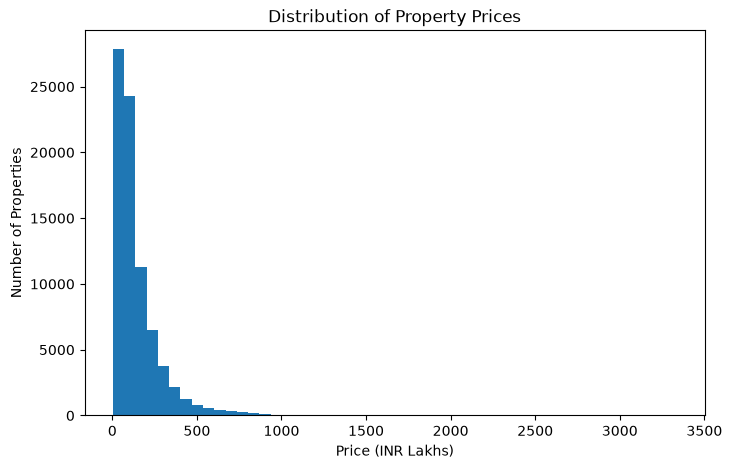

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["Price_INR_Lakhs"], bins=50)

plt.xlabel("Price (INR Lakhs)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Property Prices")

plt.show()

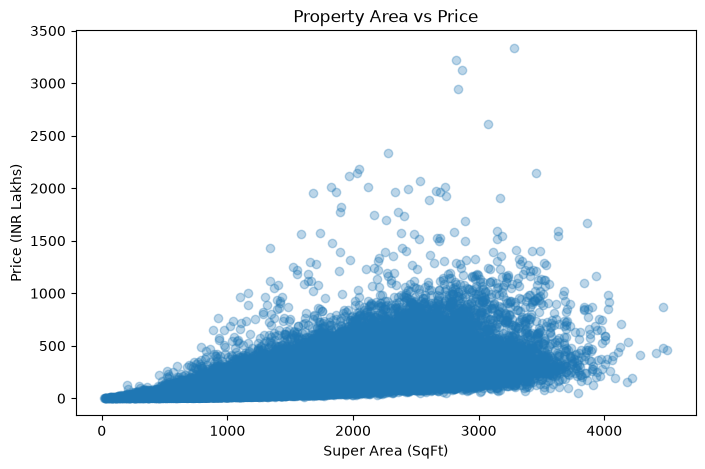

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Super_Area_SqFt"],
    df["Price_INR_Lakhs"],
    alpha=0.3
)

plt.xlabel("Super Area (SqFt)")
plt.ylabel("Price (INR Lakhs)")
plt.title("Property Area vs Price")

plt.show()

In [15]:
city_price = df.groupby("City")["Price_INR_Lakhs"].mean().sort_values()

print(city_price)

City
Jaipur         63.003885
Ahmedabad      76.146560
Kolkata        99.395469
Hyderabad     115.107165
Chennai       123.159102
Chandigarh    126.942984
Pune          133.323447
Bangalore     151.238115
Delhi         226.998967
Mumbai        308.908895
Name: Price_INR_Lakhs, dtype: float64


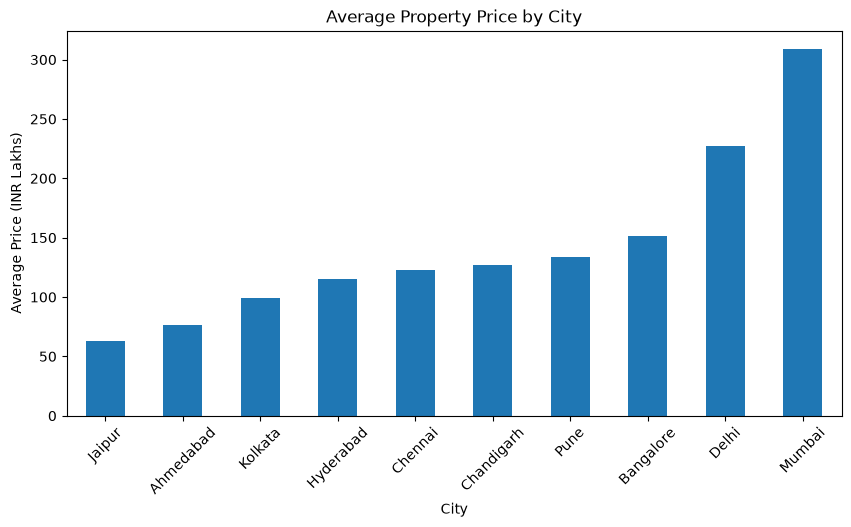

In [16]:
city_price.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("City")
plt.ylabel("Average Price (INR Lakhs)")
plt.title("Average Property Price by City")
plt.xticks(rotation=45)

plt.show()

In [17]:
bhk_price = df.groupby("BHK")["Price_INR_Lakhs"].mean()

print(bhk_price)

BHK
1    142.574754
2    142.915287
3    141.561875
4    143.070123
5    142.474100
6    146.335197
Name: Price_INR_Lakhs, dtype: float64


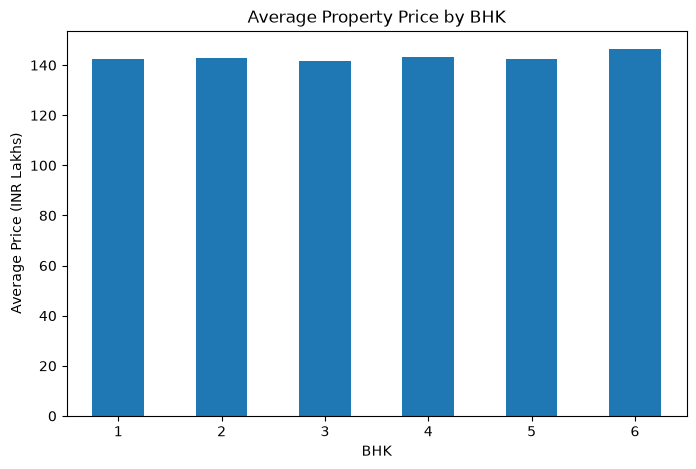

In [18]:
bhk_price.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("BHK")
plt.ylabel("Average Price (INR Lakhs)")
plt.title("Average Property Price by BHK")
plt.xticks(rotation=0)
plt.show()

In [19]:
property_type_price = df.groupby("Property_Type")["Price_INR_Lakhs"].mean()

print(property_type_price)

Property_Type
Apartment            143.231208
Builder Floor        141.503277
Independent House    142.234184
Villa                143.479415
Name: Price_INR_Lakhs, dtype: float64


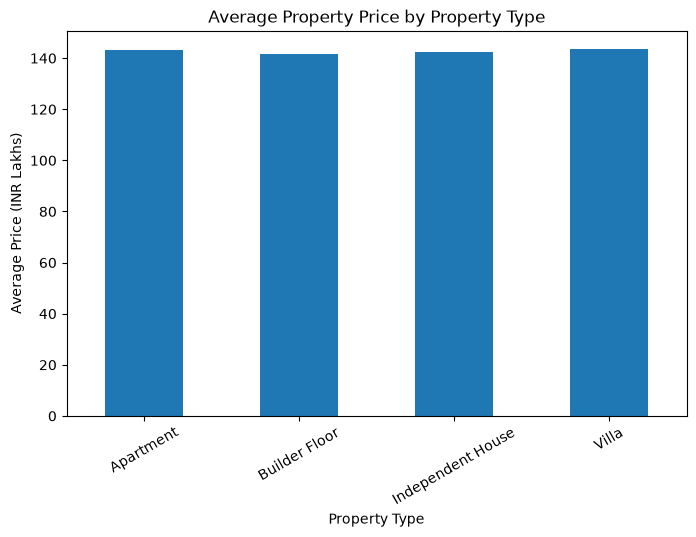

In [20]:
property_type_price.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Property Type")
plt.ylabel("Average Price (INR Lakhs)")
plt.title("Average Property Price by Property Type")
plt.xticks(rotation=30)
plt.show()

In [21]:
locality_price = df.groupby("Locality_Type")["Price_INR_Lakhs"].mean()

print(locality_price)

Locality_Type
Affordable     56.524543
Mid-Range     115.448823
Premium       284.767142
Name: Price_INR_Lakhs, dtype: float64


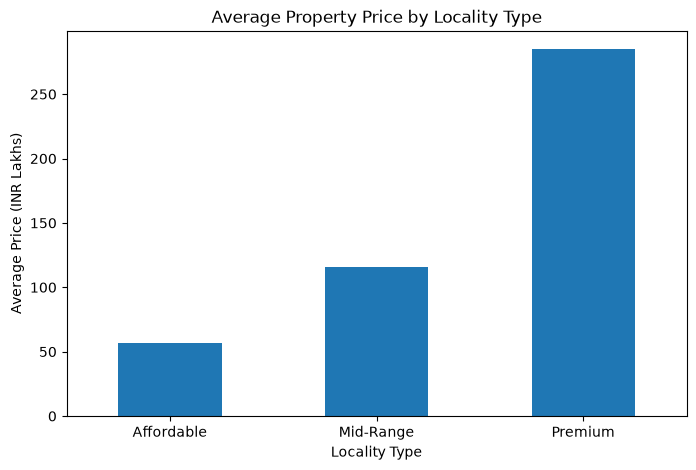

In [22]:
locality_price.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Locality Type")
plt.ylabel("Average Price (INR Lakhs)")
plt.title("Average Property Price by Locality Type")
plt.xticks(rotation=0)
plt.show()

In [23]:
furnishing_price = df.groupby("Furnishing_Status")["Price_INR_Lakhs"].mean()

print(furnishing_price)

Furnishing_Status
Furnished         141.528478
Semi-Furnished    142.448754
Unfurnished       143.878967
Name: Price_INR_Lakhs, dtype: float64


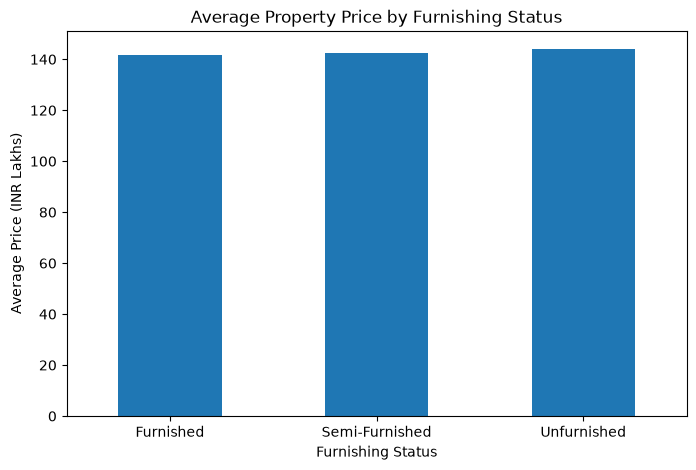

In [24]:
furnishing_price.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Furnishing Status")
plt.ylabel("Average Price (INR Lakhs)")
plt.title("Average Property Price by Furnishing Status")
plt.xticks(rotation=0)
plt.show()

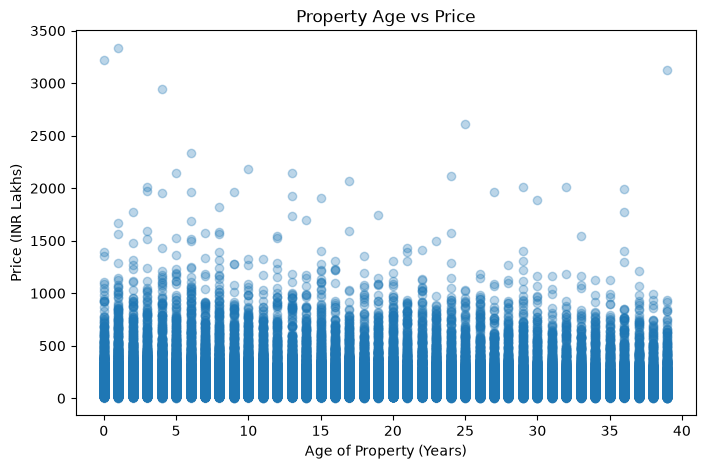

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age_of_Property"],
    df["Price_INR_Lakhs"],
    alpha=0.3
)

plt.xlabel("Age of Property (Years)")
plt.ylabel("Price (INR Lakhs)")
plt.title("Property Age vs Price")
plt.show()

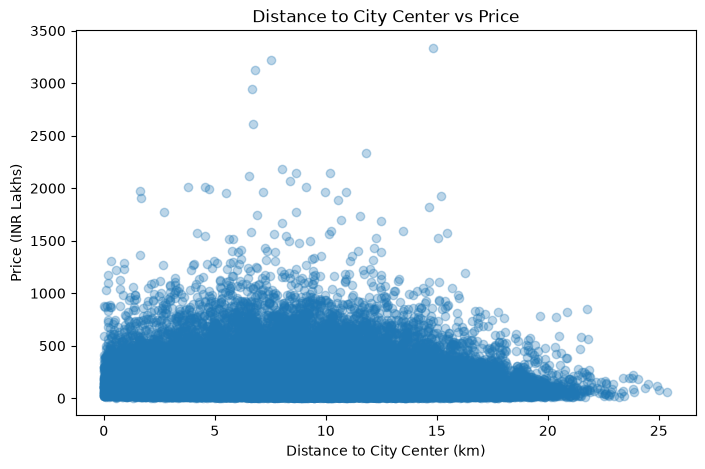

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Distance_to_City_Center_km"],
    df["Price_INR_Lakhs"],
    alpha=0.3
)

plt.xlabel("Distance to City Center (km)")
plt.ylabel("Price (INR Lakhs)")
plt.title("Distance to City Center vs Price")
plt.show()

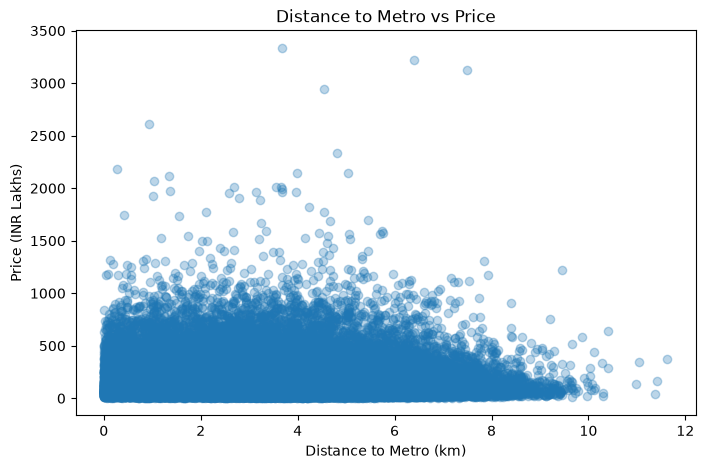

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Distance_to_Metro_km"],
    df["Price_INR_Lakhs"],
    alpha=0.3
)

plt.xlabel("Distance to Metro (km)")
plt.ylabel("Price (INR Lakhs)")
plt.title("Distance to Metro vs Price")
plt.show()

In [28]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()["Price_INR_Lakhs"].sort_values(ascending=False)

print(correlation)

Price_INR_Lakhs               1.000000
Super_Area_SqFt               0.635033
Carpet_Area_SqFt              0.623933
Parking                       0.013032
Gated_Community               0.009515
Distance_to_Metro_km          0.007584
Floor_Number                  0.002653
Lift_Available                0.002188
BHK                           0.002179
Bathrooms                     0.001643
Total_Floors                 -0.001476
Distance_to_City_Center_km   -0.090795
Age_of_Property              -0.107589
Name: Price_INR_Lakhs, dtype: float64


In [29]:
df["Price_per_SqFt"] = (
    df["Price_INR_Lakhs"] * 100000
) / df["Super_Area_SqFt"]

print(df[["Price_INR_Lakhs", "Super_Area_SqFt", "Price_per_SqFt"]].head())

   Price_INR_Lakhs  Super_Area_SqFt  Price_per_SqFt
0           127.38          1293.82     9845.264411
1           214.61          2438.03     8802.598820
2           162.56          1065.54    15256.114271
3           124.88          1611.76     7748.051819
4            94.77          1043.93     9078.194898


In [30]:
from sklearn.model_selection import train_test_split

X = df.drop("Price_INR_Lakhs", axis=1)
y = df["Price_INR_Lakhs"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (64000, 18)
Testing data: (16000, 18)


In [31]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ["Price_INR_Lakhs", "Price_per_SqFt", "Property_ID"],
    axis=1
)

y = df["Price_INR_Lakhs"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (64000, 16)
Testing data: (16000, 16)


In [32]:
print(X.columns.tolist())

['City', 'Locality_Type', 'Property_Type', 'BHK', 'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number', 'Total_Floors', 'Age_of_Property', 'Furnishing_Status', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km']


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "City",
    "Locality_Type",
    "Property_Type",
    "Furnishing_Status"
]

numeric_features = [
    "BHK",
    "Bathrooms",
    "Super_Area_SqFt",
    "Carpet_Area_SqFt",
    "Floor_Number",
    "Total_Floors",
    "Age_of_Property",
    "Parking",
    "Lift_Available",
    "Gated_Community",
    "Distance_to_Metro_km",
    "Distance_to_City_Center_km"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

print("Preprocessor ready!")

Preprocessor ready!


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained!")

Linear Regression model trained!


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = linear_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 47.940254050736065
RMSE: 86.02550215479066
R²  : 0.665746377489066


In [36]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained!")

Random Forest model trained!


In [37]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained!")

Random Forest model trained!


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
rf_pred = random_forest_model.predict(X_test)

# Evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 33.927535897309376
RMSE: 70.18892380281126
R²  : 0.7774852232662782


In [39]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2": [r2, rf_r2]
})

print(results)

               Model        MAE       RMSE        R2
0  Linear Regression  47.940254  86.025502  0.665746
1      Random Forest  33.927536  70.188924  0.777485


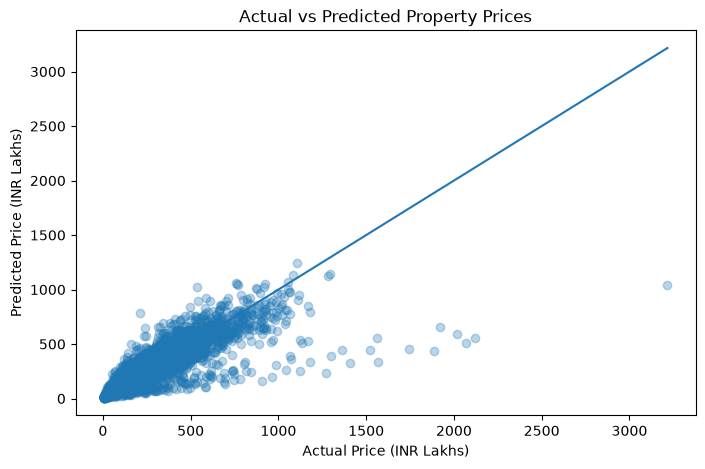

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.3
)

plt.xlabel("Actual Price (INR Lakhs)")
plt.ylabel("Predicted Price (INR Lakhs)")
plt.title("Actual vs Predicted Property Prices")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after one-hot encoding
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance
importance = random_forest_model.named_steps[
    "model"
].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort and show top 15
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                            Feature  Importance
22             num__Super_Area_SqFt    0.290201
8                  cat__City_Mumbai    0.187603
12       cat__Locality_Type_Premium    0.187521
4                   cat__City_Delhi    0.076241
31  num__Distance_to_City_Center_km    0.047208
26             num__Age_of_Property    0.039663
23            num__Carpet_Area_SqFt    0.031240
30        num__Distance_to_Metro_km    0.022823
25                num__Total_Floors    0.016770
6                  cat__City_Jaipur    0.016483
24                num__Floor_Number    0.014089
0               cat__City_Ahmedabad    0.013792
21                   num__Bathrooms    0.007377
20                         num__BHK    0.006040
1               cat__City_Bangalore    0.004934


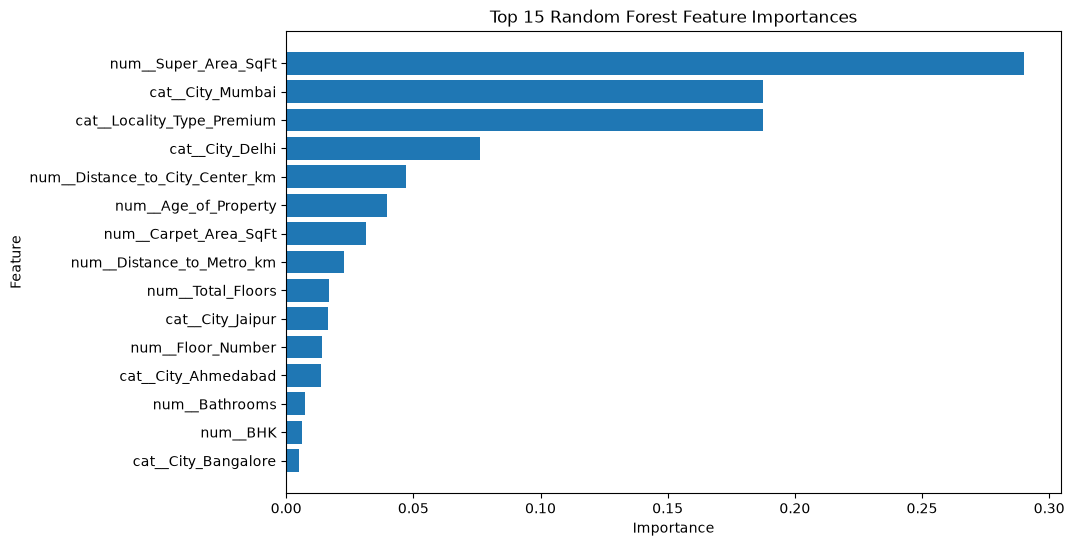

In [42]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.show()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = random_forest_model.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                            Feature  Importance
22             num__Super_Area_SqFt    0.290201
8                  cat__City_Mumbai    0.187603
12       cat__Locality_Type_Premium    0.187521
4                   cat__City_Delhi    0.076241
31  num__Distance_to_City_Center_km    0.047208
26             num__Age_of_Property    0.039663
23            num__Carpet_Area_SqFt    0.031240
30        num__Distance_to_Metro_km    0.022823
25                num__Total_Floors    0.016770
6                  cat__City_Jaipur    0.016483
24                num__Floor_Number    0.014089
0               cat__City_Ahmedabad    0.013792
21                   num__Bathrooms    0.007377
20                         num__BHK    0.006040
1               cat__City_Bangalore    0.004934


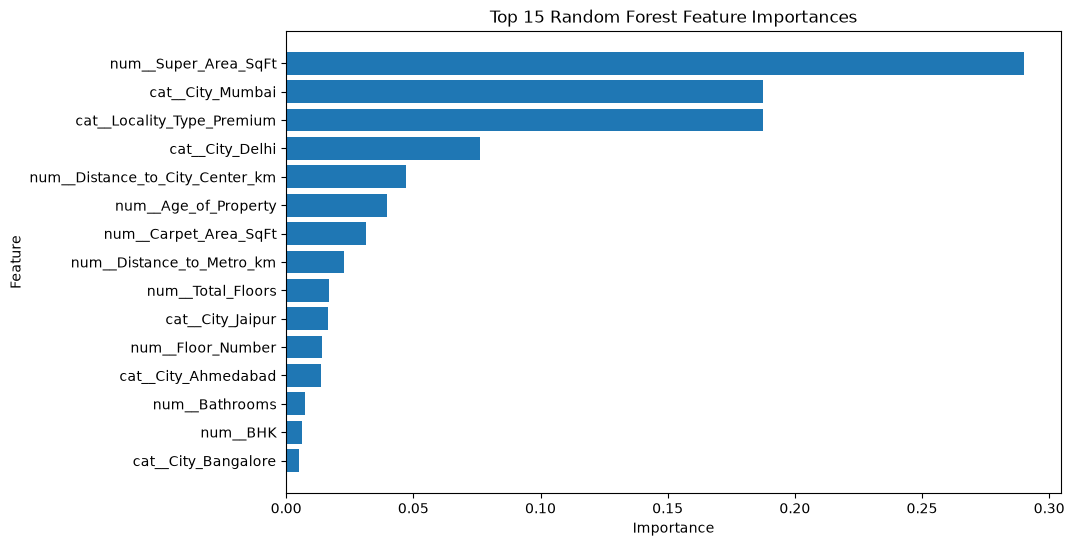

In [44]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.show()

In [45]:
new_property = pd.DataFrame({
    "City": ["Chennai"],
    "Locality_Type": ["Premium"],
    "Property_Type": ["Apartment"],
    "BHK": [3],
    "Bathrooms": [2],
    "Super_Area_SqFt": [1500],
    "Carpet_Area_SqFt": [1200],
    "Floor_Number": [5],
    "Total_Floors": [10],
    "Age_of_Property": [5],
    "Furnishing_Status": ["Semi-Furnished"],
    "Parking": [1],
    "Lift_Available": [1],
    "Gated_Community": [1],
    "Distance_to_Metro_km": [2.0],
    "Distance_to_City_Center_km": [8.0]
})

predicted_price = random_forest_model.predict(new_property)

print("Predicted Price:", predicted_price[0], "Lakhs")

Predicted Price: 151.97163596768314 Lakhs


In [46]:
import joblib

joblib.dump(
    random_forest_model,
    "random_forest_real_estate_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [47]:
import joblib

loaded_model = joblib.load(
    "random_forest_real_estate_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [48]:
loaded_prediction = loaded_model.predict(new_property)

print("Prediction from saved model:", loaded_prediction[0], "Lakhs")

Prediction from saved model: 151.97163596768314 Lakhs


In [49]:
print("FINAL MODEL RESULTS")
print("-------------------")
print("Model: Random Forest Regressor")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

FINAL MODEL RESULTS
-------------------
Model: Random Forest Regressor
MAE : 33.927535897309376
RMSE: 70.18892380281126
R²  : 0.7774852232662782
